In [10]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

In [11]:
hdul = fits.open("Planet_Lightcurve.fits")
data = hdul[1].data

time = data['time [days]']
raw_flux = data['flux    ']

hdul.close()

In [12]:
#placeholder
cleaned_time = time
cleaned_flux = raw_flux


In [13]:
#add one 10% solar flare outlier outside the transit

outlier_index = 20

flare_flux = cleaned_flux.copy()
flare_flux[outlier_index] = cleaned_flux[outlier_index] * 1.10

In [14]:
#calculate N-sigma significance

sigma_cleaned = np.std(cleaned_flux)

deviation = flare_flux[outlier_index] - np.mean(cleaned_flux)

N_sigma = deviation / sigma_cleaned

print("Standard deviation of cleaned flux:", sigma_cleaned)
print("Solar flare deviation:", deviation)
print("N-sigma significance:", N_sigma)

Standard deviation of cleaned flux: 0.008588310477699354
Solar flare deviation: 0.08556174417749274
N-sigma significance: 9.962581627628012


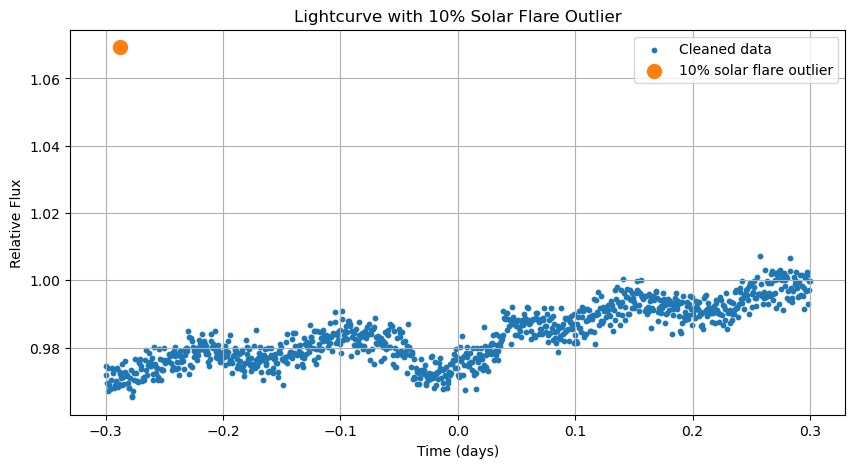

In [15]:
#cleaned data with solar flare outlier

plt.figure(figsize=(10,5))

plt.scatter(cleaned_time, cleaned_flux, s=10, label="Cleaned data")
plt.scatter(cleaned_time[outlier_index], flare_flux[outlier_index],
            s=100, label="10% solar flare outlier")

plt.xlabel("Time (days)")
plt.ylabel("Relative Flux")
plt.title("Lightcurve with 10% Solar Flare Outlier")
plt.legend()
plt.grid(True)

plt.savefig("part5.pdf")
plt.show()

In [16]:
if abs(N_sigma) > 3:
    print("The solar flare produces a large enough deviation from the cleaned lightcurve to be considered statistically significant.")
else:
    print("The solar flare does not produce a large enough deviation from the cleaned lightcurve to be considered statistically significant.")

The solar flare produces a large enough deviation from the cleaned lightcurve to be considered statistically significant.


In [17]:
print("N-sigma significance:", N_sigma)


N-sigma significance: 9.962581627628012
